In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
import pandas as pd

# Get the absolute path to the src directory, similar to the previous notebook style
# This assumes your 'utils' module is in a 'src' directory,
# and your notebook is in a directory that is a sibling to 'src'.
# Adjust if your project structure is different.
src_path = os.path.abspath(os.path.join(os.getcwd(), "../src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)


# Get the absolute path to the src directory
src_path = os.path.abspath(os.path.join(os.getcwd(), "../"))

# Add src_path to the system path
sys.path.insert(0, src_path)

from utils import mappings


# Define the input path for the new data
INPUT_PATH = "../../data/processed/7_temporal_collab_types.csv"
# Output path for the figure
FIGURE_OUTPUT_PATH = "../../results/figures/multi_subfield_collaboration_trends.pdf"

In [2]:
# YEARS will be determined dynamically from the data


def plot_multisubfield_trends(
    df_wide,
    years_list,
    total_publications_series,
    top5_highest=True,
    top5_by_volume=True,
):
    """
    Create a plot showing trends in multi-subfield publication percentages.

    Parameters:
    -----------
    df_wide : pandas.DataFrame
        DataFrame with subfields as index and years as columns, containing multi-subfield percentages.
    years_list : list
        List of years (as strings) to plot.
    total_publications_series : pandas.Series
        Series with total publications per subfield.
    top5_highest : bool, optional
        If True, show highest values; if False, show lowest. Default is True.
    top5_by_volume : bool, optional
        If True, select by publication volume; if False, select by multi-subfield collaboration percentage.
        Default is True.
    """
    # Set seaborn's research paper theme
    sns.set_theme(style="whitegrid", context="paper", font_scale=2.3)

    # Create figure and axis
    fig, ax = plt.subplots(
        figsize=(16, 8)
    )  # Increased height for better legend spacing

    # Select subfields based on criteria
    # Make a copy to avoid SettingWithCopyWarning if df_wide is a slice
    df_selection_basis = df_wide.copy()

    if top5_by_volume:
        # Sort by total publications (remove "Total" row if it exists in total_publications_series)
        if "Total" in total_publications_series.index:
            current_total_publications = total_publications_series.drop("Total")
        else:
            current_total_publications = total_publications_series

        sorted_subfields_indices = current_total_publications.sort_values(
            ascending=not top5_highest
        ).index
        title_suffix = (
            "Highest Publication Volume"
            if top5_highest
            else "Lowest Publication Volume"
        )
    else:
        # Sort by average multi-subfield collaboration percentage
        # Ensure 'Total' row is not included in this calculation if it exists in df_selection_basis
        df_for_avg = df_selection_basis
        if "Total" in df_for_avg.index:
            df_for_avg = df_for_avg.drop("Total")

        # Ensure years_list contains only columns present in df_for_avg
        valid_years_for_avg = [
            year for year in years_list if year in df_for_avg.columns
        ]
        if not valid_years_for_avg:
            print(
                f"Warning: No valid year columns found in df_for_avg for calculating average. Subfields: {df_for_avg.index.tolist()}, Columns: {df_for_avg.columns.tolist()}"
            )
            # Fallback or handle error appropriately - here, we'll proceed, which might lead to empty sorted_subfields_indices
            df_for_avg["Average_MultiSubfield_Percentage"] = pd.Series(
                index=df_for_avg.index, dtype="float64"
            )
        else:
            df_for_avg["Average_MultiSubfield_Percentage"] = df_for_avg[
                valid_years_for_avg
            ].mean(axis=1)

        sorted_subfields_indices = (
            df_for_avg["Average_MultiSubfield_Percentage"]
            .sort_values(ascending=not top5_highest)
            .index
        )
        title_suffix = (
            "Highest Multi-Subfield Collaboration"
            if top5_highest
            else "Lowest Multi-Subfield Collaboration"
        )
        if (
            "Average_MultiSubfield_Percentage" in df_selection_basis.columns
        ):  # Clean up added column
            df_selection_basis.drop(
                "Average_MultiSubfield_Percentage", axis=1, inplace=True
            )
        if (
            "Average_MultiSubfield_Percentage" in df_for_avg.columns
        ):  # Clean up added column from the copy too
            df_for_avg.drop("Average_MultiSubfield_Percentage", axis=1, inplace=True)

    selected_subfields = sorted_subfields_indices[:5]

    # Plot selected subfields
    for subfield in selected_subfields:
        if subfield not in df_wide.index:
            print(
                f"Warning: Subfield '{subfield}' not found in pivoted data. Skipping."
            )
            continue
        short_label = mappings.SUBFIELDS_SHORT.get(
            subfield, subfield
        )  # Use mapping or original name
        color = mappings.COLOUR_PALETTE.get(
            short_label, None
        )  # Use mapped color or seaborn default
        marker = mappings.MARKERS.get(short_label, "o")  # Use mapped marker or default

        ax.plot(
            years_list,  # Original years_list for x-axis
            df_wide.loc[subfield, years_list],
            marker=marker,
            linewidth=2,
            markersize=8,
            color=color,  # Let seaborn pick if color is None
            label=short_label,
        )

    # Configure plot
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.set_xlabel("Year")
    ax.set_ylabel("Multi-Subfield Publications (%)")  # Updated Y-axis label
    ax.set_xticks(years_list)  # Ensure all years are shown as ticks
    ax.set_xticklabels(years_list)  # Ensure year labels are correct
    # ax.set_ylim(0, 50)  # Adjust Y-axis limit if necessary (e.g., 0-100 or data-driven)
    # ax.set_title(f"Top 5 Subfields by {title_suffix}", fontsize=20, pad=20) # Optional title

    # Create sorted legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:  # Proceed only if there are items to show in legend
        sorted_handles_labels = sorted(zip(labels, handles), key=lambda x: x[0])
        sorted_labels, sorted_handles = zip(*sorted_handles_labels)

        ax.legend(
            sorted_handles,
            sorted_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.15),  # Adjusted y for more space
            ncol=len(
                selected_subfields
            ),  # Adjust ncol dynamically, max 3 for readability
            title="Subfields",
            frameon=True,
            fontsize="small",  # Adjust legend font size
        )
    else:
        print("Warning: No data plotted, legend will be empty.")

    # Adjust layout
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Adjust rect to ensure title/legend fit

    plt.savefig(
        fname=FIGURE_OUTPUT_PATH,  # Updated output filename
        format="pdf",
        bbox_inches="tight",
    )
    print(f"Plot saved to {FIGURE_OUTPUT_PATH}")
    return fig

Plot saved to ../../results/figures/multi_subfield_collaboration_trends.pdf


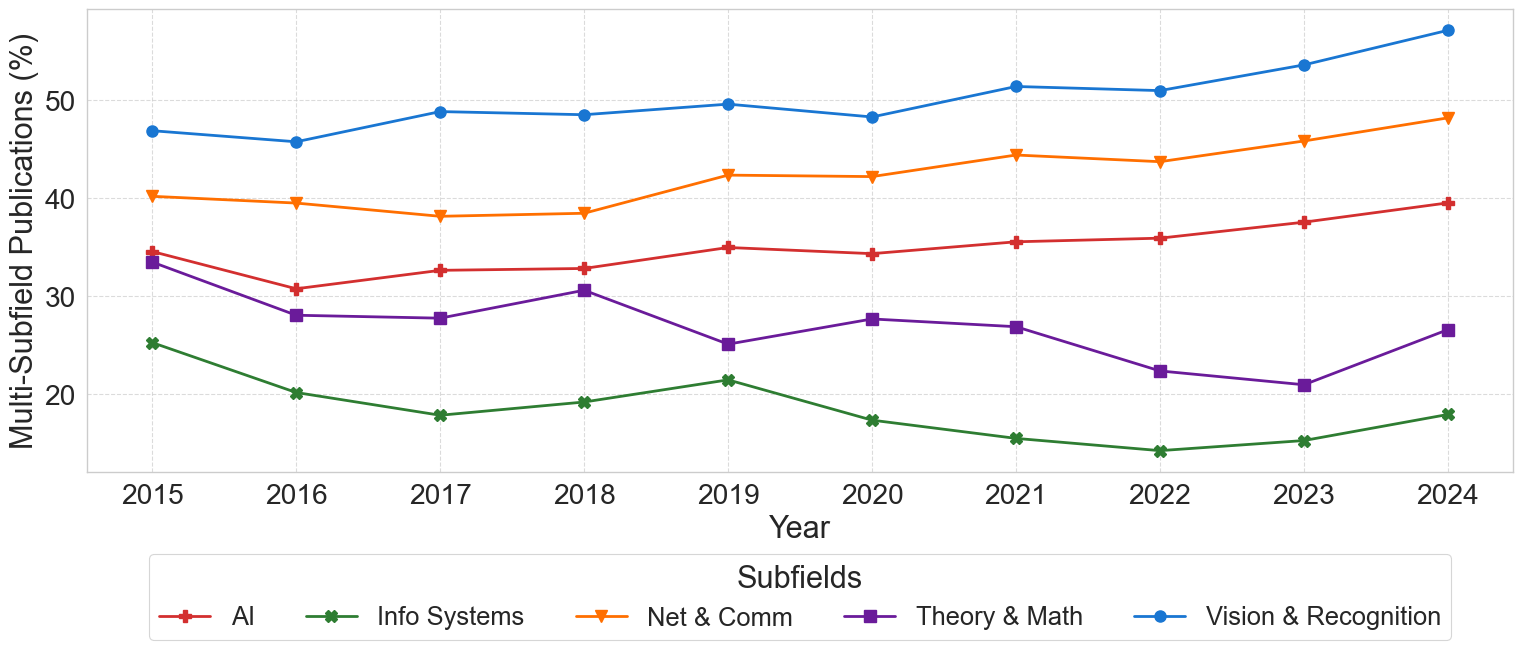

In [3]:
# 1. Read and prepare the data
try:
    multisubfield_df = pd.read_csv(INPUT_PATH)
except FileNotFoundError:
    print(f"Error: Input file not found at {INPUT_PATH}")
    sys.exit(1)  # Or handle more gracefully in a notebook, e.g. raise error

# Ensure 'publication_year' is treated as string for pivoting and consistency
multisubfield_df["publication_year"] = multisubfield_df["publication_year"].astype(str)

# Pivot to wide format using 'multi_subfield_percentage'
# Filter out "Total" row before pivoting if it's for display of individual subfields
df_for_pivot = multisubfield_df[multisubfield_df["subfield_display"] != "Total"]

if df_for_pivot.empty:
    print(
        f"Error: No data available for pivoting after filtering out 'Total' row or empty input. Check {INPUT_PATH}"
    )
    # In a notebook, you might want to stop execution or print a more visible warning
    # For now, we'll let it proceed, which will likely cause errors later or an empty plot.
    # A better approach might be to sys.exit(1) or raise an exception if this is critical.
    wide_df = pd.DataFrame()  # Create an empty DataFrame to avoid NameError
else:
    wide_df = df_for_pivot.pivot(
        index="subfield_display",
        columns="publication_year",
        values="multi_subfield_percentage",  # Key change: use multi_subfield_percentage
    )
    # .astype(float) is not strictly necessary if data is already float, but good for ensuring
    wide_df = wide_df.fillna(
        0
    )  # Fill NaNs that might result from pivot (e.g. subfield has no data for a year)

# 2. Generate the years list from actual data columns (which are strings)
if not wide_df.empty:
    YEARS = sorted(wide_df.columns.tolist())
else:
    YEARS = []

if not YEARS:
    print(
        "Warning: No year columns found after pivoting. Plot might be empty or fail. Check data integrity."
    )
    # If wide_df was empty, YEARS will be empty.

# Calculate total publications per subfield for sorting by volume
# Use the original multisubfield_df for this, as it contains 'total_publications'
total_publications = multisubfield_df.groupby("subfield_display")[
    "total_publications"
].sum()

# 3. Plot using the corrected data
# Check if wide_df is empty or YEARS is empty before attempting to plot
if wide_df.empty or not YEARS:
    print(
        "Skipping plot generation as there is no data to plot (wide_df is empty or no YEARS found)."
    )
else:
    # Example: Plot top 5 by highest multi-subfield collaboration percentage
    fig = plot_multisubfield_trends(
        wide_df,
        YEARS,
        total_publications_series=total_publications,
        top5_highest=True,
        top5_by_volume=True,
    )
    # Example: Plot top 5 by highest publication volume
    # fig = plot_multisubfield_trends(wide_df, YEARS, total_publications_series=total_publications, top5_highest=True, top5_by_volume=True)

    plt.show()